<a href="https://colab.research.google.com/github/PSriChandana/Data-Imputation/blob/main/Inferential_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import scipy.stats

In [3]:
cars_data=pd.read_csv('cars_sampled.csv')

In [4]:
cars=cars_data.copy()

In [5]:
cars=cars[(cars.yearOfRegistration <=2018)
        & (cars.yearOfRegistration>=1950)
        & (cars.price >=100)
        & (cars.price <=150000)
        & (cars.powerPS >=10)
        & (cars.powerPS <= 500)]


All hypotheses will be checked on the sample of data.


1Q. Three years back, the average price of a usedd car was 6000 $. Has
it changed now?

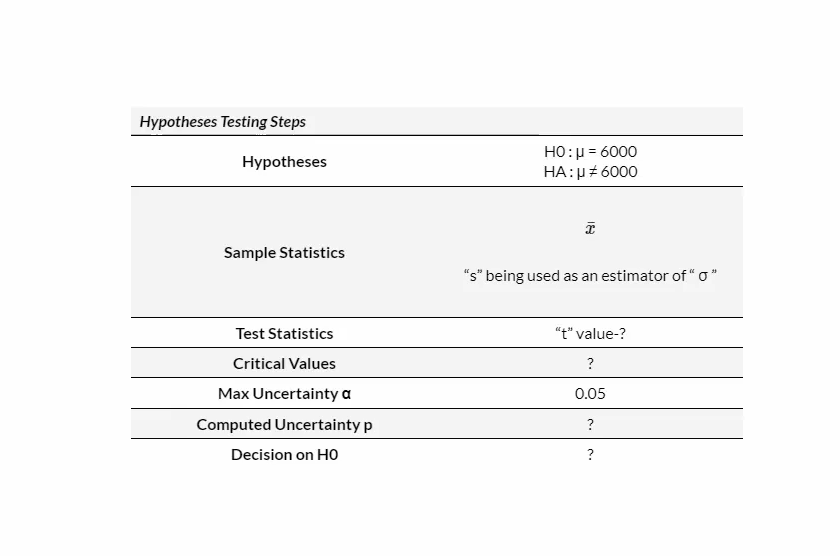


In [6]:
sample_size=1000
sample1=cars.sample(sample_size,random_state=0)

In [7]:
#postulated mean-hypothesized mean
pos_mean=6000
print(sample1['price'].mean())

5997.217


In [8]:
from scipy.stats import ttest_1samp
statistic,pvalue=ttest_1samp(sample1['price'],pos_mean)
print(statistic,pvalue)

#pvalue is the uncertainity we calculated

-0.012200376272741554 0.9902681855608537


Calculating the degreeof freedom

So we calculate the critical values so we set a significance value. The significance value is taken


In [9]:
n=len(cars['price'])
#degree of freedom = n-1
df=n-1
print(n,df)
#this is the number of independent data

10507 10506


In [10]:
#Significance Level
alpha=0.05

In [11]:
#import scipy.stats and import ppf(point point function) to calculate the critical value
from scipy.stats import t
#Critical values from standard Distribution
cv = t.ppf([alpha/2,1-alpha/2],df)
#This is a two tail test, so this becomes the input to the ppf
print(cv)

[-1.96018981  1.96018981]


In [12]:
#Because the teststatistics value lies betweent he critical values so we dont reject the null hyspothesis
#so we can conclude that the mean price is equal to 6000 $

Test for Proportionality

Q. Three years back, % of used car with automatic transmission were 23%. Has it changed now?
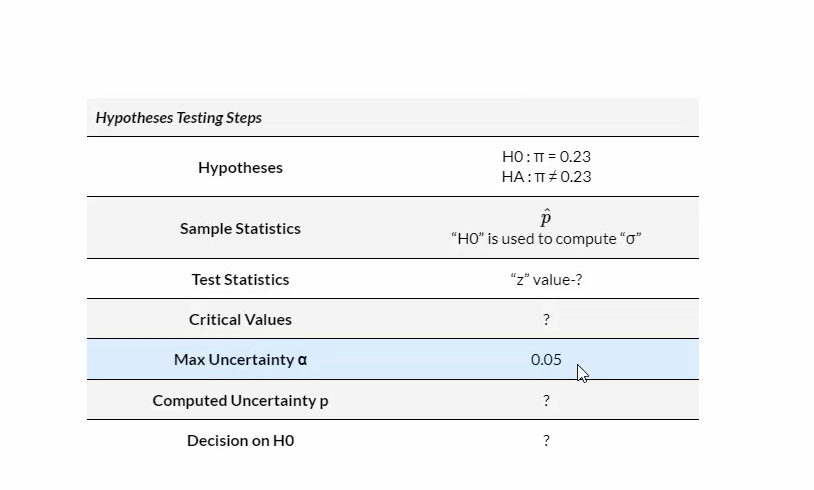

In [13]:
from statsmodels.stats.proportion import proportions_ztest

In [14]:
# No. of gearbox='automatic'
count = sample1['gearbox'].value_counts()[1]
nobs=len(sample1['gearbox'])
p0=0.23 #Hypothesized value


/tmp/ipykernel_988/1256917130.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = sample1['gearbox'].value_counts()[1]


In [15]:
statistic_oneprop,pvalue_oneprop= proportions_ztest(count=count, nobs=nobs, value=p0, alternative='two-sided',prop_var=False)
print(statistic_oneprop,pvalue_oneprop)

0.14983228171418267 0.8808969397177204


In [16]:
#Importing normal distribution
from scipy.stats import norm

#Critical values
cv_norm = norm.ppf([alpha/2,1-alpha/2])
print(cv_norm)
#compare with the critical values

[-1.95996398  1.95996398]


The value calculated lies in the range, so we dont reject it.

**Is the mean price of cars that have 30000-60000 KM, the same as that for cars that have run 70000-90000 KM?**

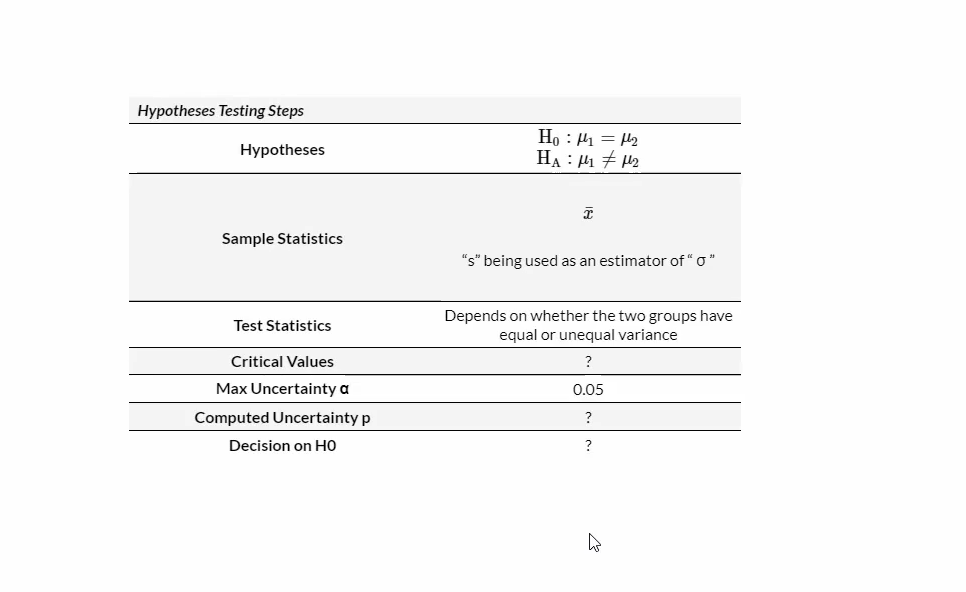

In [17]:
#subsetting records based on kilometer limits and drawing 500 samples from each
km_70000_90000=cars[(cars.kilometer <= 90000)&(cars.kilometer >= 70000)]
km_30000_60000=cars[(cars.kilometer <= 60000)&(cars.kilometer >= 30000)]

In [18]:
#Choosing 500 records randomly
sample_70000_90000=km_70000_90000.sample(500,random_state=0)
sample_30000_60000=km_30000_60000.sample(500, random_state=0)

In [19]:
#Sample variance
print(sample_70000_90000.price.var())
print(sample_30000_60000.price.var())


110848542.78019616
186977389.40871647


In [20]:
#sample mean
print(sample_70000_90000.price.mean())
print(sample_30000_60000.price.mean())

9768.058
14452.89


**Computing the F statistic**

In [21]:
from scipy.stats import f
F=sample_70000_90000.price.var()/sample_30000_60000.price.var()
print(F)

0.5928446382246294


**Calculating the degrees of freedom for the two samples**

In [22]:
df2=len(sample_70000_90000)-1
df1=len(sample_30000_60000)-1

In [23]:
scipy.stats.f.cdf(F,df1,df2)

np.float64(3.240552218503998e-09)

In [24]:
f.ppf([alpha/2,1-alpha/2],df1,df2)

array([0.83888578, 1.1920574 ])

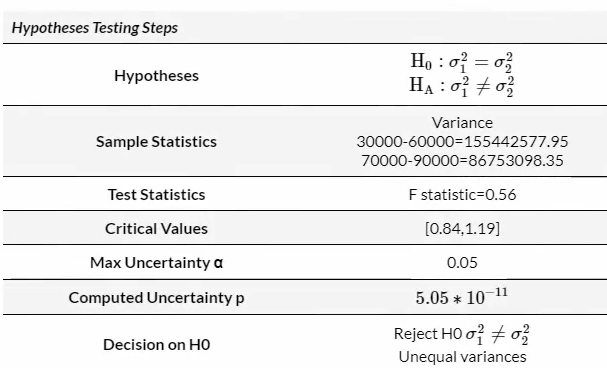

**WELCH T TEST FOR UNEQUAL VARIANCES**

In [25]:
from scipy.stats import ttest_ind
statistic_twomean,pvalue_twomean=ttest_ind(sample_30000_60000.price,sample_70000_90000.price,equal_var=False)
print(statistic_twomean, pvalue_twomean)

6.070126877847491 1.8543364164135082e-09


In [26]:
N1=len(sample_30000_60000)
N2=len(sample_70000_90000)
s12=sample_30000_60000.price.var()
s22=sample_70000_90000.price.var()
df=(((s12/N1)+(s22/N2))**2)/((((s12/N1)**2)/(N1-1))+(((s22/N2)**2)/(N2-1)))
print(df)

936.790880117244


In [27]:
cv_t=t.ppf([alpha/2,1-alpha/2],df)
print(cv_t)

[-1.96249954  1.96249954]


Null Hypothesis is rejected.

**Are the proportion petrol cars in two different time periods 2009-2013, and 2014-2018, different?**
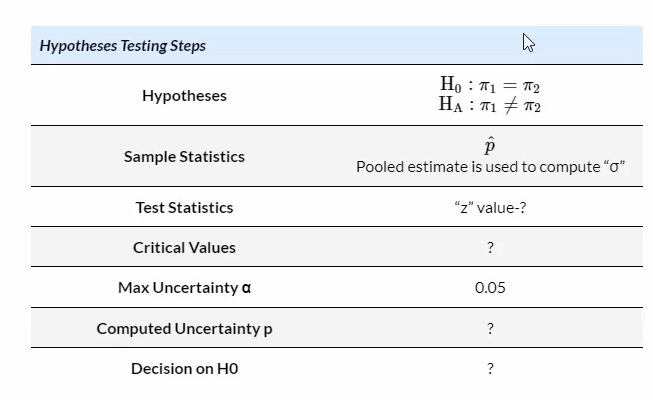

**Subsetting records based on year and drawing 1000 samples from each**

In [28]:
year_2014_2018=cars[(cars.yearOfRegistration <= 2018)&(cars.yearOfRegistration >= 2014)]
year_2009_2013=cars[(cars.yearOfRegistration <= 2013)&(cars.yearOfRegistration >=2009)]

In [33]:
sample_2014_2018=year_2014_2018.sample(100,random_state=0)
sample_2009_2013=year_2009_2013.sample(100,random_state=0)

In [36]:
from statsmodels.stats.proportion import proportions_ztest
count=[(sample_2014_2018['fuelType']=='petrol').sum(),(sample_2009_2013['fuelType']=='petrol').sum()]
nobs= [len(sample_2014_2018),len(sample_2009_2013)]

In [37]:
print(count[0]/nobs[0])
print(count[1]/nobs[1])

0.42
0.6
